In [1]:
STUDENT_NAME = "Yomna Elnikety"
STUDENT_ID = "25011181"

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("Currently allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("Currently reserved:", torch.cuda.memory_reserved() / 1e9, "GB")

CUDA available: True
Device count: 1
Device name: NVIDIA RTX 5000 Ada Generation
Currently allocated: 0.0 GB
Currently reserved: 0.0 GB


## Setup

In [3]:
from pathlib import Path
DATA_ROOT = Path("/l/users/yomna.elnikety/ENG2440_data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)


In [4]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [5]:
#imports and constants
import os
os.environ["TORCH_HOME"] = str(OUT / "torch_cache")

import random, copy, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc, brier_score_loss)
from sklearn.calibration import calibration_curve
from IPython.display import display, Markdown

#three independent training seeds for better representation and small batches and epochs
SPLIT_SEED = 2440
TRAIN_SEEDS = [2440, 2441, 2442]
IMAGE_SIZE = 224
BATCH_SIZE = 32
HEAD_EPOCHS, FINETUNE_EPOCHS = 3, 7
DEVICE = torch.device("cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else "cpu")
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)
    
seed_everything(SPLIT_SEED)
print("Device:", DEVICE, "| split seed:", SPLIT_SEED, "| training seeds:", TRAIN_SEEDS)
print("Python", platform.python_version(), "PyTorch", torch.__version__)
assert DATA_ROOT.is_dir() and LABEL_FILE.exists() and MAPPING_FILE.exists()


Device: cuda | split seed: 2440 | training seeds: [2440, 2441, 2442]
Python 3.10.21 PyTorch 2.5.1+cu121


## Task A

In [6]:
#Loading a sample DICOM 
sample_path = dicom_files[0]
ds = pydicom.dcmread(sample_path)

print("Sample path:", sample_path)
print("Patient ID:", ds.PatientID)
print("Image shape:", ds.pixel_array.shape)
print("Photometric interpretation:", ds.get("PhotometricInterpretation", "Not available"))
print("View position:", ds.get("ViewPosition", "Not available"))

Sample path: /l/users/yomna.elnikety/ENG2440_data/images/images_wget/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.15186.1517874384.188322/1.2.276.0.7230010.3.1.3.8323329.15186.1517874384.188321/1.2.276.0.7230010.3.1.4.8323329.15186.1517874384.188323.dcm
Patient ID: ee6302ef-9219-49a2-b637-c6d7545f2bc2
Image shape: (1024, 1024)
Photometric interpretation: MONOCHROME2
View position: AP


In [7]:
# Loading label file and mapping file 
labels = pd.read_csv(LABEL_FILE, dtype={"patientId": str})
mapping = pd.read_csv(MAPPING_FILE, dtype=str)
assert labels.Target.notna().all() and set(labels.Target.unique()) <= {0, 1}
assert not mapping.patientId.duplicated().any(), "mapping must be one row per examination."
exam = labels.groupby("patientId", as_index=False).Target.max().rename(columns={"Target":"target"})
exam = exam.merge(mapping, on="patientId", how="left", validate="one_to_one")
assert exam.nih_patient_id.notna().all()
paths = sorted(DATA_ROOT.rglob("*.dcm"))
lookup = {p.stem.replace("_", "."): str(p) for p in paths}
assert len(lookup) == len(paths), "Duplicate file identifiers need investigation."
exam["file_path"] = exam.patientId.map(lookup)
assert exam.file_path.notna().all(), "Some labelled examinations have no image."
exam = exam.sort_values("patientId").reset_index(drop=True)

#Unique values and class distribution
print("DICOM files:", len(paths), "Labelled examinations:", len(exam),
      "Source patients in analysed cohort:", exam.nih_patient_id.nunique())
counts = exam.target.value_counts().reindex([0,1], fill_value=0)
display(pd.DataFrame({"count": counts, "proportion": counts / len(exam)}))
headers = []
for p in exam.file_path:
    d = pydicom.dcmread(p, stop_before_pixels=True)
    headers.append({"rows": int(d.Rows), "columns": int(d.Columns),
                    "photometric": str(d.get("PhotometricInterpretation", "Unknown")),
                    "view": str(d.get("ViewPosition", "Unknown")) or "Unknown",
                    "sex": str(d.get("PatientSex", "Unknown")) or "Unknown"})
exam = pd.concat([exam, pd.DataFrame(headers)], axis=1)
for fields in [["rows", "columns"], ["photometric"], ["view"]]:
    display(exam.groupby(fields, dropna=False).size().rename("count").to_frame())



DICOM files: 25684 Labelled examinations: 25684 Source patients in analysed cohort: 11171


,count,proportion
target,,
0,20025,0.779668
1,5659,0.220332


,,count
rows,columns,
1024,1024,25684


,count
photometric,
MONOCHROME2,25684


,count
view,
AP,11705
PA,13979


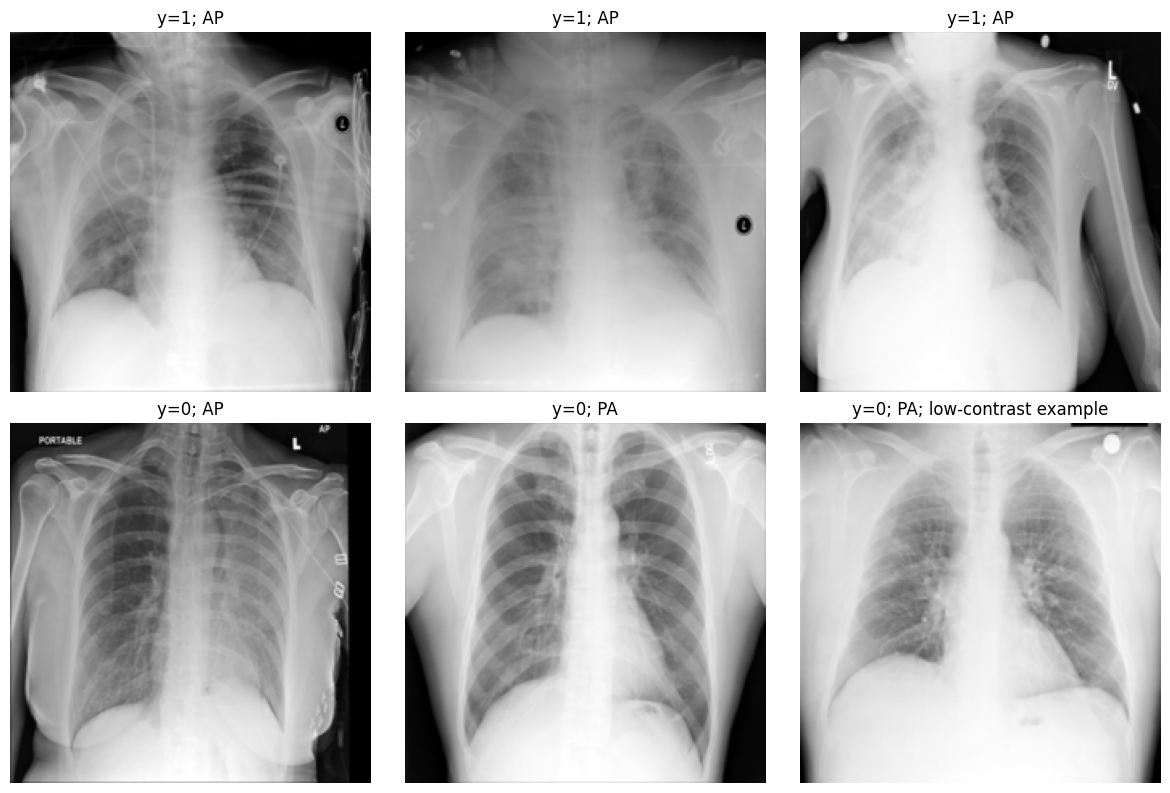

Unusual example selected by lowest post-scaling intensity SD in a 64-image sample: 1.2.276.0.7230010.3.1.4.8323329.13630.1517874373.708265 SD: 40.951560717574786
This is an acquisition/appearance example, not a claim of an additional diagnosis.


In [8]:
# Returning a uint8 image with aspect preservation
def read_gray(path):
    ds = pydicom.dcmread(path)
    x = ds.pixel_array.astype(np.float32)
    assert x.ndim == 2, "Expected a single grayscale frame."
    x = x * float(ds.get("RescaleSlope", 1)) + float(ds.get("RescaleIntercept", 0))
    if str(ds.PhotometricInterpretation) == "MONOCHROME1": x = x.max() + x.min() - x
    lo, hi = np.percentile(x, [.5, 99.5])
    x = np.clip((x-lo)/max(float(hi-lo), 1e-6), 0, 1)
    im = Image.fromarray(np.uint8(np.round(255*x)))
    im.thumbnail((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
    canvas = Image.new("L", (IMAGE_SIZE, IMAGE_SIZE), color=0)
    canvas.paste(im, ((IMAGE_SIZE-im.width)//2, (IMAGE_SIZE-im.height)//2))
    return canvas

CACHE = OUT / "pixels_224_v1"
CACHE.mkdir(exist_ok=True)
def cached_gray(row):
    path = CACHE / (row.patientId + ".png")
    if not path.exists(): read_gray(row.file_path).save(path)
    with Image.open(path) as im: return im.copy()

# Six representative DICOM examples
selected = exam[exam.target.eq(1)].sample(3, random_state=SPLIT_SEED)
selected = pd.concat([selected, exam[exam.target.eq(0)].sample(2, random_state=SPLIT_SEED)])
candidates = exam[~exam.patientId.isin(selected.patientId)].sample(64, random_state=SPLIT_SEED)
contrasts = [np.asarray(cached_gray(r)).std() for r in candidates.itertuples()]
unusual = candidates.iloc[[int(np.argmin(contrasts))]]
selected = pd.concat([selected, unusual])
fig, axes = plt.subplots(2,3,figsize=(12,8))
for i,(ax,r) in enumerate(zip(axes.flat, selected.itertuples())):
    ax.imshow(cached_gray(r), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"y={r.target}; {r.view}" + ("; low-contrast example" if i==5 else ""))
    ax.axis("off")
fig.tight_layout(); fig.savefig(OUT/"representative_images.png", dpi=150); plt.show()
print("Unusual example selected by lowest post-scaling intensity SD in a 64-image sample:", unusual.patientId.iloc[0], "SD:", min(contrasts))
print("This is an acquisition/appearance example, not a claim of an additional diagnosis.")

## Task B

In [9]:
#Leakage safe train/val/test split at patient level
patients = exam.groupby("nih_patient_id", as_index=False).target.max()
trainval, test_people = train_test_split(patients, test_size=.15, random_state=SPLIT_SEED, stratify=patients.target)
train_people, val_people = train_test_split(trainval, test_size=.15/.85, random_state=SPLIT_SEED, stratify=trainval.target)
groups = {"train": set(train_people.nih_patient_id), "val": set(val_people.nih_patient_id), "test": set(test_people.nih_patient_id)}
for a, b in [("train","val"),("train","test"),("val","test")]:
    assert groups[a].isdisjoint(groups[b])
assignment = {p: name for name, ids in groups.items() for p in ids}
exam["split"] = exam.nih_patient_id.map(assignment)
assert exam.split.notna().all() and exam.groupby("nih_patient_id").split.nunique().max() == 1
split_summary = exam.groupby("split").agg(examinations=("patientId","size"), patients=("nih_patient_id","nunique"), positives=("target","sum"), prevalence=("target","mean"))
display(split_summary.loc[["train","val","test"]])
exam.to_csv(OUT / "split_manifest.csv", index=False)
frames = {s: exam[exam.split == s].reset_index(drop=True) for s in groups}

,examinations,patients,positives,prevalence
split,,,,
train,18257,7819,3996,0.218875
val,3739,1676,820,0.219310
test,3688,1676,843,0.228579


## Task C

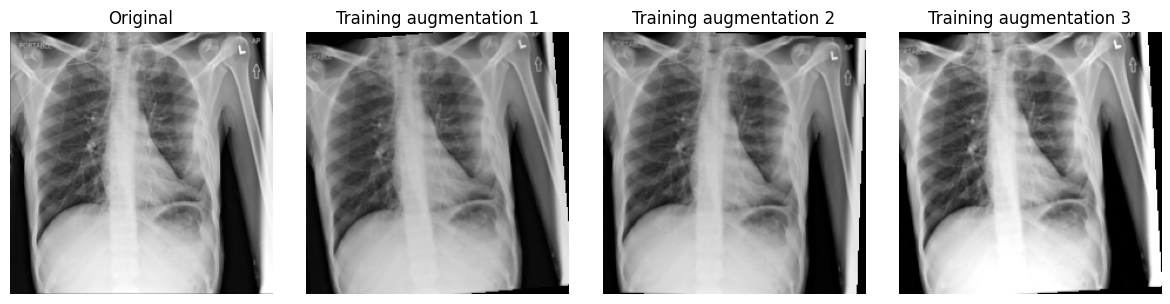

In [10]:
# Training Augmentation
augmentation = transforms.Compose([
    transforms.RandomAffine(degrees=5, translate=(.03,.03), interpolation=transforms.InterpolationMode.BILINEAR, fill=0), transforms.ColorJitter(brightness=.1, contrast=.1)])
normalise = transforms.Normalize([.485,.456,.406], [.229,.224,.225])
def image_tensor(im): return normalise(TF.to_tensor(im).repeat(3,1,1))

train = frames["train"]
im = cached_gray(train.iloc[0])
fig,axes=plt.subplots(1,4,figsize=(12,3))
for i,ax in enumerate(axes):
    ax.imshow(im if i==0 else augmentation(im),cmap="gray",vmin=0,vmax=255)
    ax.set_title("Original" if i==0 else f"Training augmentation {i}"); ax.axis("off")
fig.tight_layout(); fig.savefig(OUT/"augmentations.png",dpi=150); plt.show()

#Viewing normalised images
class ChestDataset(Dataset):
    def __init__(self, frame, training=False):
        self.frame=frame.reset_index(drop=True); self.training=training
    def __len__(self): return len(self.frame)
    def __getitem__(self,index):
        row=self.frame.iloc[index]; im=cached_gray(row)
        if self.training: im=augmentation(im)
        return image_tensor(im), torch.tensor(float(row.target))
def loader(frame, training=False, seed=SPLIT_SEED):
    return DataLoader(ChestDataset(frame,training),batch_size=BATCH_SIZE,shuffle=training, num_workers=0,generator=torch.Generator().manual_seed(seed))


## Task D

In [11]:
#Baseline
def summary_features(frame):
    result=[]
    for row in frame.itertuples():
        x=np.asarray(cached_gray(row),dtype=np.float32)/255
        result.append([x.mean(),x.std(),*np.percentile(x,[10,25,75,90])])
    return np.asarray(result,dtype=np.float32)
features={s:summary_features(frames[s]) for s in ["train","val"]}
feature_mean=features["train"].mean(0)
feature_std=features["train"].std(0).clip(1e-6)
X={s:torch.tensor((v-feature_mean)/feature_std) for s,v in features.items()}
y={s:torch.tensor(frames[s].target.to_numpy(),dtype=torch.float32) for s in frames}

def fit_linear(lr, decay):
    seed_everything(SPLIT_SEED)
    model=nn.Linear(6,1)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=decay)
    best_ap=-np.inf; best=None; stale=0
    for epoch in range(500):
        opt.zero_grad(); loss=nn.functional.binary_cross_entropy_with_logits(model(X["train"]).squeeze(1),y["train"])
        loss.backward(); opt.step()
        with torch.no_grad(): p=model(X["val"]).squeeze(1).sigmoid().numpy()
        ap=average_precision_score(y["val"].numpy(),p)
        if ap>best_ap+1e-6: best_ap=ap; best=copy.deepcopy(model.state_dict()); stale=0
        else: stale+=1
        if stale>=40: break
    model.load_state_dict(best)
    return model,best_ap,epoch+1
linear_trials=[]; linear_models=[]

#Small grid 
for lr in [.01,.03]:
    for decay in [0.,.01]:
        model,ap,epochs=fit_linear(lr,decay); linear_models.append(model)
        linear_trials.append(dict(lr=lr,weight_decay=decay,val_AP=ap,epochs=epochs))
linear_trials=pd.DataFrame(linear_trials)
baseline=linear_models[int(linear_trials.val_AP.to_numpy().argmax())]
display(linear_trials)
with torch.no_grad(): baseline_val=baseline(X["val"]).squeeze(1).sigmoid().numpy()

majority=int(frames["train"].target.mean()>=.5)
print("Training majority label:",majority,"training prevalence:",frames["train"].target.mean())
torch.save({"state_dict":baseline.state_dict(),"mean":feature_mean.tolist(),"std":feature_std.tolist()},OUT/"linear.pt")

,lr,weight_decay,val_AP,epochs
0,0.01,0.00,0.425741,500
1,0.01,0.01,0.425268,500
2,0.03,0.00,0.435520,500
3,0.03,0.01,0.435251,500


Training majority label: 0 training prevalence: 0.21887495207317742


## Task E

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to outputs/torch_cache/hub/checkpoints/resnet18-f37072fd.pth
100.0%
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarn

2440 False {'stage': 'head', 'epoch': 1, 'train_loss': 0.417687398492686, 'val_loss': 0.3961921733756472, 'val_AP': 0.6118972020940715}


/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(tr

2440 False {'stage': 'head', 'epoch': 2, 'train_loss': 0.3971077350044313, 'val_loss': 0.37948849452118977, 'val_AP': 0.6194271760963106}


/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(tr

...

/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(tr

2442 False {'stage': 'fine_tune', 'epoch': 9, 'train_loss': 0.30521256763735155, 'val_loss': 0.3659051386995665, 'val_AP': 0.6624575236762852}


/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(tr

2442 False {'stage': 'fine_tune', 'epoch': 10, 'train_loss': 0.2850461521571533, 'val_loss': 0.37099550833004497, 'val_AP': 0.6747680351072392}


/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)


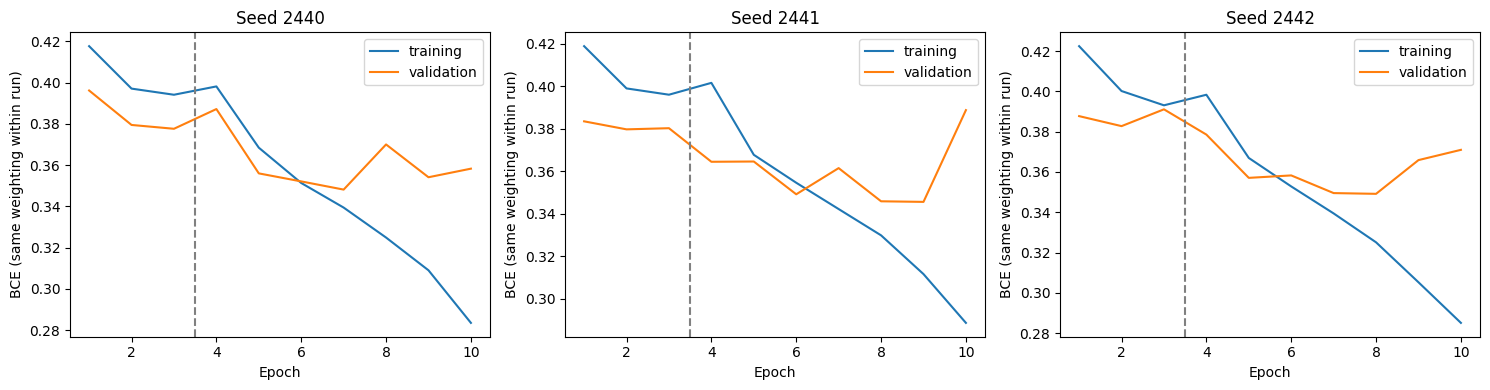

Seed 2440: last train loss 0.2835, last val loss 0.3583; minimum val loss 0.3481 at epoch 7.
No strong late-loss divergence by this heuristic, inspect curves and AP for under/overfitting.
Seed 2441: last train loss 0.2886, last val loss 0.3888; minimum val loss 0.3456 at epoch 9.
Late validation loss rises while training loss falls, consistent with overfitting.
Seed 2442: last train loss 0.2850, last val loss 0.3710; minimum val loss 0.3491 at epoch 8.
Late validation loss rises while training loss falls, consistent with overfitting.


In [12]:
#Training the pretrained CNN
def make_cnn():
    model=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc=nn.Linear(model.fc.in_features,1)
    return model.to(DEVICE)

def predict(model, frame):
    model.eval(); values=[]
    with torch.no_grad():
        for x,_ in loader(frame): values.append(model(x.to(DEVICE)).flatten().sigmoid().cpu().numpy())
    return np.concatenate(values)


#Training from end to end
def run_cnn(seed, weighted):
    seed_everything(seed)
    model=make_cnn()
    pos_weight=float((frames["train"].target==0).sum()/(frames["train"].target==1).sum()) if weighted else 1.
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight,device=DEVICE))
    history=[]; global_best=-np.inf; global_state=None
    for stage,epochs,lr in [("head",HEAD_EPOCHS,1e-3),("fine_tune",FINETUNE_EPOCHS,1e-4)]:
        for name,p in model.named_parameters():
            p.requires_grad=name.startswith("fc.") or (stage=="fine_tune" and name.startswith("layer4."))
        opt=torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],lr=lr,weight_decay=1e-4)
        stage_best=-np.inf; stage_state=None
        for epoch in range(epochs):
            model.train()
            for m in model.modules():
                if isinstance(m,nn.BatchNorm2d): m.eval()
            total=0.; count=0
            for x,t in loader(frames["train"],True,seed+epoch):
                x,t=x.to(DEVICE),t.to(DEVICE)
                opt.zero_grad(set_to_none=True); logits=model(x).flatten()
                loss=criterion(logits,t); loss.backward(); opt.step()
                total+=float(loss.detach())*len(t); count+=len(t)
            model.eval(); val_loss=0.; probs=[]
            with torch.no_grad():
                for x,t in loader(frames["val"]):
                    x,t=x.to(DEVICE),t.to(DEVICE); logits=model(x).flatten()
                    val_loss+=float(criterion(logits,t))*len(t)
                    probs.append(logits.sigmoid().cpu().numpy())
            ap=average_precision_score(frames["val"].target,np.concatenate(probs))
            history.append(dict(stage=stage,epoch=len(history)+1,train_loss=total/count,
                                val_loss=val_loss/len(frames["val"]),val_AP=ap))
            print(seed,weighted,history[-1],flush=True)
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            if ap>stage_best: stage_best=ap; stage_state=state
            if ap>global_best: global_best=ap; global_state=state
        model.load_state_dict(stage_state)
    model.load_state_dict(global_state)
    stem=f"cnn_seed{seed}_weighted{int(weighted)}"
    torch.save({"state_dict":global_state,"seed":seed,"weighted":weighted, "val_AP":global_best,"split_seed":SPLIT_SEED},OUT/(stem+".pt"))
    pd.DataFrame(history).to_csv(OUT/(stem+"_history.csv"),index=False)
    return dict(model=model,seed=seed,weighted=weighted,history=pd.DataFrame(history), val_prob=predict(model,frames["val"]))


#compare weighting strategies on one seed
ablation=[run_cnn(TRAIN_SEEDS[0],weighted) for weighted in [False,True]]
ablation_table=pd.DataFrame([dict(weighted=r["weighted"],
    val_AP=average_precision_score(frames["val"].target,r["val_prob"]),
    val_Brier=brier_score_loss(frames["val"].target,r["val_prob"])) for r in ablation])
display(ablation_table)
winner=int(ablation_table.val_AP.to_numpy().argmax())
headline_weighted=ablation[winner]["weighted"]
runs=[ablation[winner]]+[run_cnn(seed,headline_weighted) for seed in TRAIN_SEEDS[1:]]
headline=runs[0]
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,r in zip(axes,runs):
    h=r["history"]; ax.plot(h.epoch,h.train_loss,label="training"); ax.plot(h.epoch,h.val_loss,label="validation")
    ax.axvline(HEAD_EPOCHS+.5,color="gray",ls="--"); ax.set_title(f"Seed {r['seed']}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE (same weighting within run)"); ax.legend()
fig.tight_layout(); fig.savefig(OUT/"learning_curves.png",dpi=150); plt.show()

#simmple heuristic
for r in runs:
    h=r["history"]; end=h.iloc[-1]; best=h.loc[h.val_loss.idxmin()]
    print(f"Seed {r['seed']}: last train loss {end.train_loss:.4f}, last val loss {end.val_loss:.4f}; "
          f"minimum val loss {best.val_loss:.4f} at epoch {int(best.epoch)}.")
    print("Late validation loss rises while training loss falls, consistent with overfitting."
          if end.val_loss>best.val_loss*1.05 and end.train_loss<h.iloc[0].train_loss else
          "No strong late-loss divergence by this heuristic, inspect curves and AP for under/overfitting.")

## Task F

Frozen before test inference: {'linear': {'screening': 0.14077869057655334, 'high_specificity': 0.31277230381965637}, '2440': {'screening': 0.1308431774377823, 'high_specificity': 0.4489484429359436}, '2441': {'screening': 0.10689175873994827, 'high_specificity': 0.40298524498939514}, '2442': {'screening': 0.14045991003513336, 'high_specificity': 0.4705664813518524}}


,weighted,n,prevalence,threshold,TN,FP,FN,TP,accuracy,sensitivity,specificity,precision,F1,ROC_AUC,AP,PR_AUC,Brier
0,False,3739,0.21931,0.5,2683,236,349,471,0.843541,0.574390,0.919150,0.666195,0.616896,0.87619,0.688438,0.688181,0.109802
1,True,3739,0.21931,0.5,2237,682,147,673,0.778283,0.820732,0.766358,0.496679,0.618851,0.87389,0.687112,0.686851,0.153061


/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)


,model,n,prevalence,threshold,TN,FP,FN,TP,accuracy,sensitivity,specificity,precision,F1,ROC_AUC,AP,PR_AUC,Brier
0,Majority,3688,0.228579,0.5,2845,0,843,0,0.771421,0.000000,1.000000,NaN,0.000000,0.500000,0.228579,0.614290,0.176425
1,Linear,3688,0.228579,0.5,2835,10,833,10,0.771421,0.011862,0.996485,0.500000,0.023175,0.698209,0.401204,0.400031,0.162375
2,CNN seed 2440,3688,0.228579,0.5,2616,229,342,501,0.845174,0.594306,0.919508,0.686301,0.636999,0.878869,0.706156,0.705855,0.109696
3,CNN seed 2441,3688,0.228579,0.5,2657,188,394,449,0.842191,0.532622,0.933919,0.704867,0.606757,0.876126,0.695809,0.695497,0.110866
4,CNN seed 2442,3688,0.228579,0.5,2591,254,338,505,0.839479,0.599051,0.910721,0.665349,0.630462,0.878833,0.708591,0.708209,0.110417


,model,rule,n,prevalence,threshold,TN,FP,FN,TP,accuracy,sensitivity,specificity,precision,F1,ROC_AUC,AP,PR_AUC,Brier
0,Linear,screening,3688,0.228579,0.140779,711,2134,88,755,0.397505,0.895611,0.249912,0.261336,0.404609,0.698209,0.401204,0.400031,0.162375
1,Linear,high_specificity,3688,0.228579,0.312772,2549,296,588,255,0.760304,0.302491,0.895958,0.462795,0.365854,0.698209,0.401204,0.400031,0.162375
2,CNN seed 2440,screening,3688,0.228579,0.130843,1875,970,84,759,0.714208,0.900356,0.659051,0.438982,0.590202,0.878869,0.706156,0.705855,0.109696
3,CNN seed 2440,high_specificity,3688,0.228579,0.448948,2572,273,310,533,0.841920,0.632266,0.904042,0.661290,0.646452,0.878869,0.706156,0.705855,0.109696
4,CNN seed 2441,screening,3688,0.228579,0.106892,1883,962,85,758,0.716106,0.899170,0.661863,0.440698,0.591494,0.876126,0.695809,0.695497,0.110866
5,CNN seed 2441,high_specificity,3688,0.228579,0.402985,2566,279,302,541,0.842462,0.641756,0.901933,0.659756,0.650631,0.876126,0.695809,0.695497,0.110866
6,CNN seed 2442,screening,3688,0.228579,0.140460,1902,943,82,761,0.722072,0.902728,0.668541,0.446596,0.597566,0.878833,0.708591,0.708209,0.110417
7,CNN seed 2442,high_specificity,3688,0.228579,0.470566,2570,275,309,534,0.841649,0.633452,0.903339,0.660074,0.646489,0.878833,0.708591,0.708209,0.110417


CNN test AP: mean=0.7035, sample SD=0.0068; difference vs linear=0.3023.
Improvement exceeds observed one SD seed variation: True
Three seeds quantify optimisation variation, not a statistical significance test or patient sampling uncertainty.


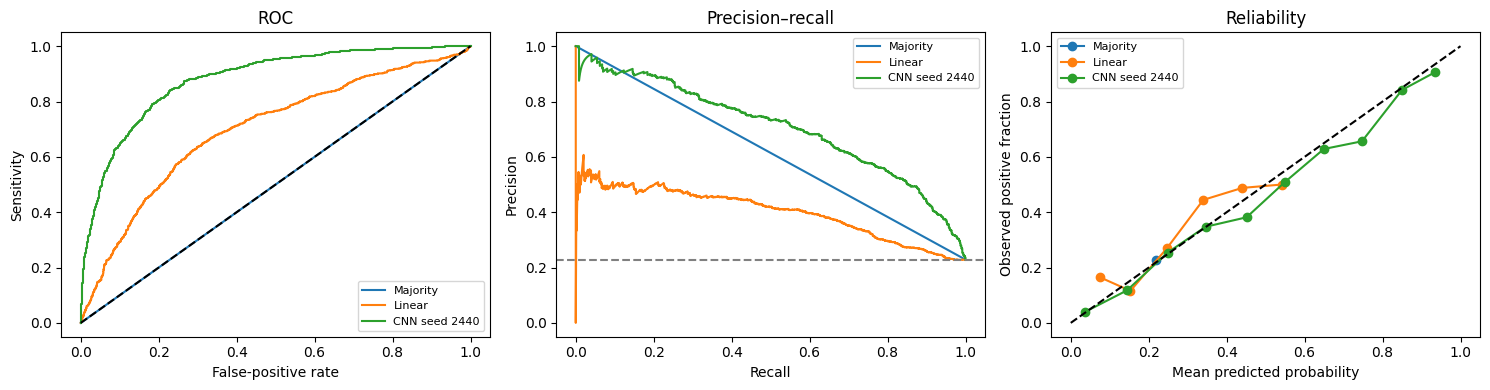

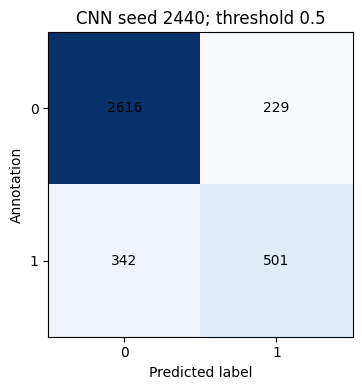

In [13]:
#Metric application for evaluation
def metrics(y,p,threshold=.5):
    y=np.asarray(y,dtype=int); p=np.asarray(p); pred=p>=threshold
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    div=lambda a,b: float(a/b) if b else np.nan
    two=len(np.unique(y))==2
    precision,recall,_=precision_recall_curve(y,p) if two else (None,None,None)
    return dict(n=len(y),prevalence=float(y.mean()),threshold=float(threshold),
        TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp),accuracy=div(tp+tn,len(y)), sensitivity=div(tp,tp+fn),specificity=div(tn,tn+fp),precision=div(tp,tp+fp),
        F1=div(2*tp,2*tp+fp+fn),ROC_AUC=roc_auc_score(y,p) if two else np.nan,
        AP=average_precision_score(y,p) if two else np.nan, PR_AUC=auc(recall,precision) if two else np.nan,Brier=brier_score_loss(y,p))

def choose_thresholds(y,p):
    fpr,tpr,thresholds=roc_curve(y,p,drop_intermediate=False)
    thresholds=np.where(np.isfinite(thresholds),thresholds,np.nextafter(float(np.max(p)),np.inf))
    screen=np.flatnonzero(tpr>=.90)
    specific=np.flatnonzero(1-fpr>=.90)
    a=max(screen,key=lambda i:(1-fpr[i],thresholds[i]))
    b=max(specific,key=lambda i:(tpr[i],thresholds[i]))
    return {"screening":float(thresholds[a]),"high_specificity":float(thresholds[b])}

baseline_thresholds=choose_thresholds(frames["val"].target,baseline_val)
for r in runs: r["thresholds"]=choose_thresholds(frames["val"].target,r["val_prob"])
frozen={"linear":baseline_thresholds,**{str(r["seed"]):r["thresholds"] for r in runs}}
(OUT/"frozen_thresholds.json").write_text(json.dumps(frozen,indent=2))
print("Frozen before test inference:",frozen)
display(pd.DataFrame([dict(weighted=r["weighted"],**metrics(frames["val"].target,r["val_prob"])) for r in ablation]))

features_test=summary_features(frames["test"])
with torch.no_grad():
    baseline_test=baseline(torch.tensor((features_test-feature_mean)/feature_std)).flatten().sigmoid().numpy()
for r in runs: r["test_prob"]=predict(r["model"],frames["test"])
ytest=frames["test"].target.to_numpy()
majority_prob=np.full(len(ytest),frames["train"].target.mean())
comparison=[dict(model="Majority",**metrics(ytest,majority_prob)), dict(model="Linear",**metrics(ytest,baseline_test))]
comparison += [dict(model=f"CNN seed {r['seed']}",**metrics(ytest,r["test_prob"])) for r in runs]
comparison=pd.DataFrame(comparison); display(comparison); comparison.to_csv(OUT/"test_comparison.csv",index=False)
operating=[]

for name,p,thresholds in [("Linear",baseline_test,baseline_thresholds)]+[
    (f"CNN seed {r['seed']}",r["test_prob"],r["thresholds"]) for r in runs]:
    for rule,t in thresholds.items(): operating.append(dict(model=name,rule=rule,**metrics(ytest,p,t)))
operating=pd.DataFrame(operating); display(operating); operating.to_csv(OUT/"operating_points.csv",index=False)
aps=np.array([average_precision_score(ytest,r["test_prob"]) for r in runs])
delta=aps.mean()-average_precision_score(ytest,baseline_test)
print(f"CNN test AP: mean={aps.mean():.4f}, sample SD={aps.std(ddof=1):.4f}; difference vs linear={delta:.4f}.")
print("Improvement exceeds observed one SD seed variation:",bool(delta>aps.std(ddof=1)))
print("Three seeds quantify optimisation variation, not a statistical significance test or patient sampling uncertainty.")
p=headline["test_prob"]
fig,axes=plt.subplots(1,3,figsize=(15,4))


for name,prob in [("Majority",majority_prob),("Linear",baseline_test),("CNN seed 2440",p)]:
    fpr,tpr,_=roc_curve(ytest,prob); prec,rec,_=precision_recall_curve(ytest,prob)
    axes[0].plot(fpr,tpr,label=name); axes[1].plot(rec,prec,label=name)
    observed,predicted=calibration_curve(ytest,prob,n_bins=10,strategy="uniform")
    axes[2].plot(predicted,observed,"o-",label=name)
axes[0].plot([0,1],[0,1],"k--"); axes[0].set(xlabel="False-positive rate",ylabel="Sensitivity",title="ROC")
axes[1].axhline(ytest.mean(),color="gray",ls="--"); axes[1].set(xlabel="Recall",ylabel="Precision",title="Precision–recall")
axes[2].plot([0,1],[0,1],"k--"); axes[2].set(xlabel="Mean predicted probability",ylabel="Observed positive fraction",title="Reliability")

for ax in axes: ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT/"evaluation_curves.png",dpi=150); plt.show()
cm=confusion_matrix(ytest,p>=.5,labels=[0,1])
fig,ax=plt.subplots(figsize=(4,4)); ax.imshow(cm,cmap="Blues")
for (i,j),n in np.ndenumerate(cm): ax.text(j,i,str(n),ha="center",va="center")
ax.set(xticks=[0,1],yticks=[0,1],xlabel="Predicted label",ylabel="Annotation",title="CNN seed 2440; threshold 0.5")
fig.tight_layout(); plt.show()
predictions=frames["test"][["patientId","nih_patient_id","target","view","sex"]].copy()
predictions["linear_probability"]=baseline_test
for r in runs: predictions[f"cnn_{r['seed']}"]=r["test_prob"]
predictions.to_csv(OUT/"test_predictions.csv",index=False)


## Task G

Correct examples included: True Incorrect examples included: True


,field,group,n,prevalence,threshold,TN,FP,FN,TP,accuracy,sensitivity,specificity,precision,F1,ROC_AUC,AP,PR_AUC,Brier
0,view,AP,1701,0.389183,0.5,858,181,200,462,0.776014,0.697885,0.825794,0.718507,0.708046,0.844031,0.775175,0.774843,0.154810
1,view,PA,1987,0.091092,0.5,1758,48,142,39,0.904378,0.215470,0.973422,0.448276,0.291045,0.829219,0.347569,0.344160,0.071076
2,sex,F,1527,0.206942,0.5,1118,93,136,180,0.850033,0.569620,0.923204,0.659341,0.611205,0.871957,0.658238,0.657403,0.107340
3,sex,M,2161,0.243869,0.5,1498,136,206,321,0.841740,0.609108,0.916769,0.702407,0.652439,0.882751,0.734069,0.733619,0.111361


Small or single-class groups have unstable/undefined metrics. View/sex differences are descriptive, not causal fairness claims.


/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/yomna.elnikety/.conda/envs/my_project/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(tr

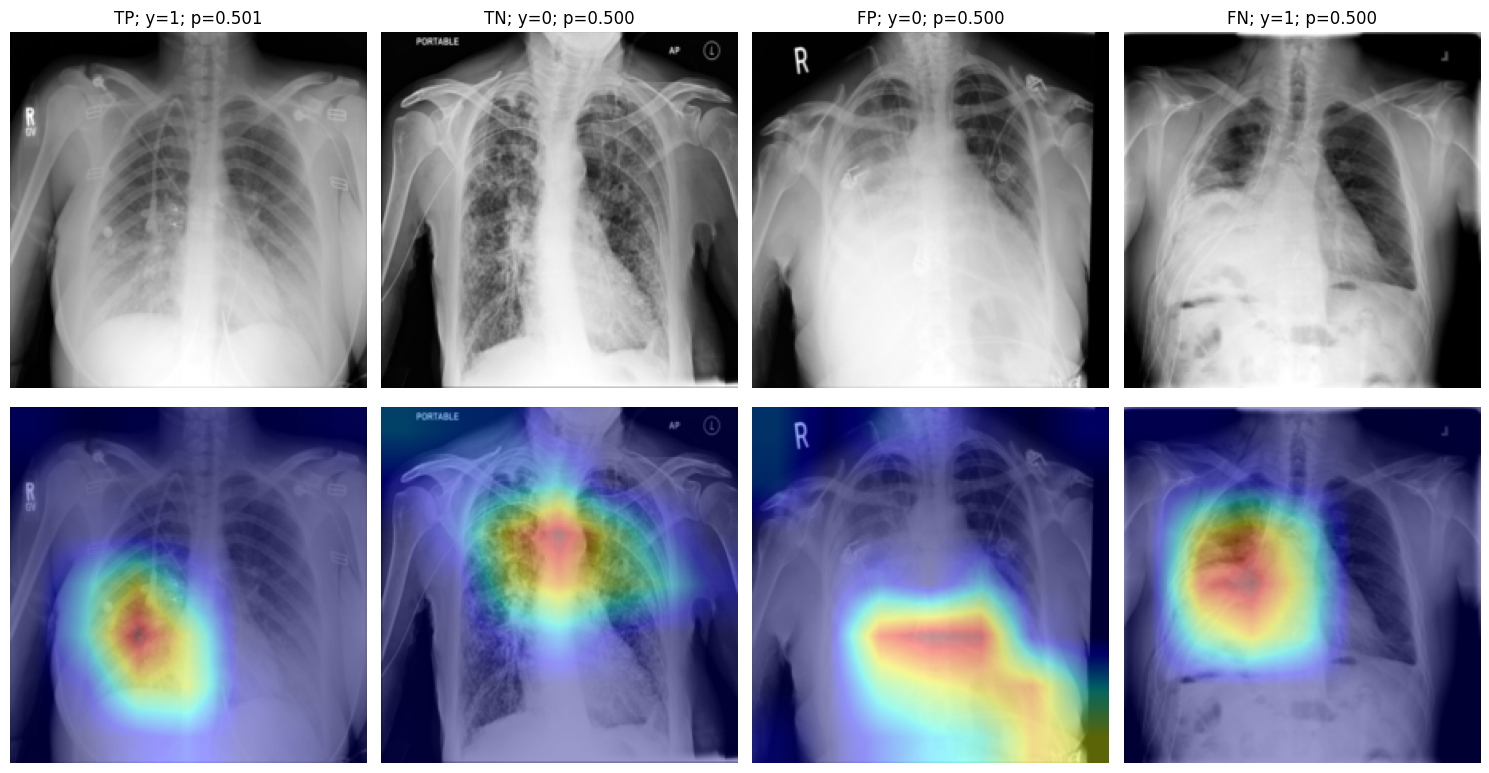

Test row 138 border CAM fraction 0.0730513334274292 border area fraction 0.2955994897959184
Test row 3113 border CAM fraction 0.08918433636426926 border area fraction 0.2955994897959184
Test row 1392 border CAM fraction 0.24337022006511688 border area fraction 0.2955994897959184
Test row 551 border CAM fraction 0.017804162576794624 border area fraction 0.2955994897959184


In [14]:
#Results interpretation
pred=p>=.5
categories={"TP":np.flatnonzero((ytest==1)&pred),"TN":np.flatnonzero((ytest==0)&~pred),
            "FP":np.flatnonzero((ytest==0)&pred),"FN":np.flatnonzero((ytest==1)&~pred)}
chosen=[]; chosen_names=[]
for name,ids in categories.items():
    if len(ids): chosen.append(int(ids[np.argmin(np.abs(p[ids]-.5))])); chosen_names.append(name)
    else: print("No",name,"examples at threshold 0.5.")
for i in np.argsort(np.abs(p-.5)):
    if len(chosen)>=4: break
    if int(i) not in chosen: chosen.append(int(i)); chosen_names.append("Additional")
print("Correct examples included:",any(pred[i]==ytest[i] for i in chosen),
      "Incorrect examples included:",any(pred[i]!=ytest[i] for i in chosen))

subgroups=[]
for field in ["view","sex"]:
    for value,indices in frames["test"].groupby(field).groups.items():
        ids=np.asarray(list(indices)); subgroups.append(dict(field=field,group=value,**metrics(ytest[ids],p[ids])))
subgroups=pd.DataFrame(subgroups); display(subgroups)
subgroups.to_csv(OUT/"subgroup_metrics.csv",index=False)
print("Small or single-class groups have unstable/undefined metrics. View/sex differences are descriptive, not causal fairness claims.")

def gradcam(model, x):
    """Gradient-weighted activation map for the positive logit; hooks removed reliably."""
    model.eval(); captured={}
    def hook(module, inputs, output): captured["activation"]=output
    handle=model.layer4[-1].register_forward_hook(hook)
    try:
        x=x.detach().to(DEVICE).requires_grad_(True)
        logit=model(x).flatten()[0]
        activation=captured["activation"]
        gradient=torch.autograd.grad(logit,activation)[0]
        weights=gradient.mean(dim=(2,3),keepdim=True)
        cam=(weights*activation).sum(dim=1,keepdim=True).relu()
        cam=nn.functional.interpolate(cam,size=x.shape[-2:],mode="bilinear",align_corners=False)[0,0]
        cam=cam/(cam.max()+1e-8)
        return cam.detach().cpu().numpy()
    finally: handle.remove()

fig,axes=plt.subplots(2,4,figsize=(15,8))
for col,(idx,name) in enumerate(zip(chosen,chosen_names)):
    im=cached_gray(frames["test"].iloc[idx]); heat=gradcam(headline["model"],image_tensor(im).unsqueeze(0))
    for row in [0,1]: axes[row,col].imshow(im,cmap="gray",vmin=0,vmax=255); axes[row,col].axis("off")
    axes[0,col].set_title(f"{name}; y={ytest[idx]}; p={p[idx]:.3f}")
    axes[1,col].imshow(heat,cmap="jet",alpha=.4,vmin=0,vmax=1)
fig.tight_layout(); fig.savefig(OUT/"errors_gradcam.png",dpi=150); plt.show()
for idx in chosen:
    im=cached_gray(frames["test"].iloc[idx]); heat=gradcam(headline["model"],image_tensor(im).unsqueeze(0))
    k=round(.08*IMAGE_SIZE); border=np.ones_like(heat,dtype=bool); border[k:-k,k:-k]=False
    print("Test row",idx,"border CAM fraction",float(heat[border].sum()/(heat.sum()+1e-8)),
          "border area fraction",float(border.mean()))

## Bonus 1

In [15]:
#Treshold transfer
def shifted_indices(y, prevalence, seed):
    rng=np.random.default_rng(seed); positive=np.flatnonzero(y==1); negative=np.flatnonzero(y==0)
    if y.mean()>prevalence:
        keep=min(len(positive),round(prevalence*len(negative)/(1-prevalence)))
        return np.sort(np.r_[negative,rng.choice(positive,keep,replace=False)])
    keep=min(len(negative),round((1-prevalence)*len(positive)/prevalence))
    return np.sort(np.r_[positive,rng.choice(negative,keep,replace=False)])

screen=headline["thresholds"]["screening"]
shift_results=[dict(cohort="Original",**metrics(ytest,p,screen))]

for prevalence in [.10,.40]:
    ids=shifted_indices(ytest,prevalence,SPLIT_SEED)
    shift_results.append(dict(cohort=f"Target prevalence {prevalence:.0%}",**metrics(ytest[ids],p[ids],screen)))
shift_results=pd.DataFrame(shift_results); display(shift_results)
shift_results.to_csv(OUT/"prevalence_shift.csv",index=False)

for _,row in shift_results.iloc[1:].iterrows():
    original=shift_results.iloc[0]
    print(row.cohort, {m:round(float(row[m]-original[m]),4) for m in
          ["sensitivity","specificity","precision","F1","ROC_AUC"]})

,cohort,n,prevalence,threshold,TN,FP,FN,TP,accuracy,sensitivity,specificity,precision,F1,ROC_AUC,AP,PR_AUC,Brier
0,Original,3688,0.228579,0.130843,1875,970,84,759,0.714208,0.900356,0.659051,0.438982,0.590202,0.878869,0.706156,0.705855,0.109696
1,Target prevalence 10%,3161,0.099968,0.130843,1875,970,29,287,0.683961,0.908228,0.659051,0.228321,0.364908,0.884154,0.536064,0.534742,0.080014
2,Target prevalence 40%,2107,0.400095,0.130843,832,432,84,759,0.755102,0.900356,0.658228,0.637280,0.746313,0.876441,0.825256,0.825109,0.149243


Target prevalence 10% {'sensitivity': 0.0079, 'specificity': 0.0, 'precision': -0.2107, 'F1': -0.2253, 'ROC_AUC': 0.0053}
Target prevalence 40% {'sensitivity': 0.0, 'specificity': -0.0008, 'precision': 0.1983, 'F1': 0.1561, 'ROC_AUC': -0.0024}
